## Data and county mask

The analysis uses ERA5 TXx data aggregated over Colorado counties. The county mask assigns each grid cell to a county using the county index stored in the NetCDF mask file computed from the US Counties shapefile from MetPy. Grid cells outside the county mask are assigned missing values.

For each county, **pre** denotes the county spatial average calculated before the generalized extreme-value (GEV) analysis. **Post** denotes the county spatial average calculated after the GEV analysis. The results include return levels, uncertainty quantiles, and AIC values for both cases.

In [129]:
import xarray as xr
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import cmaps
import geopandas as gpd
from matplotlib import cm

In [130]:
lon_min = -109+360
lon_max = -102+360
lat_min = 37
lat_max = 41

In [131]:
dsc = xr.open_dataset('~/data/TXx/ERA5_mask_counties_CO.nc')
dsc = dsc.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
ncounties = len(dsc['county'])
lat = dsc.lat
lon = dsc.lon

In [132]:
ds = xr.open_dataset('~/data/TXx/CONUS_TXx_ERA5_ij_glostLocSca_extremes_gev_CV_CI_COLORADO_counties300_1952_2025.zarr', engine='zarr')


In [133]:
mask = dsc['mask'].astype('int').where(dsc['mask'].astype('int')>0)

/Users/gahe5417/miniconda3/envs/Rpy/lib/python3.14/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [134]:
maskic = xr.zeros_like(mask)*np.nan
for ic in range(0,ncounties):
  icounty = ds['county'][ic].data.item()
  maskic = xr.where(mask==icounty,ic,maskic)

In [135]:
ds = ds.assign_coords(lat = lat)
ds = ds.assign_coords(lon = lon)
ds = ds.assign_coords(mask = mask)

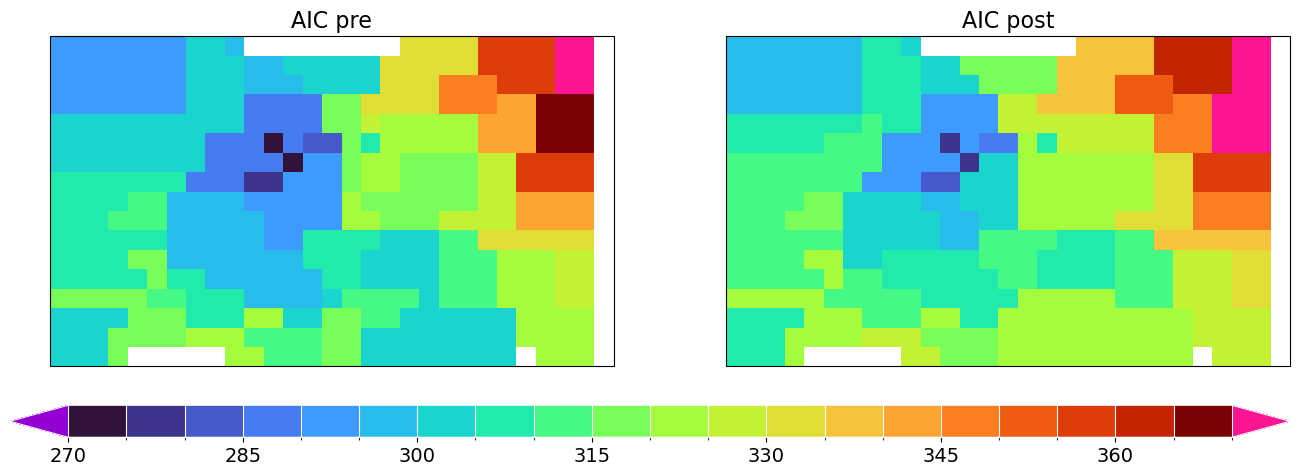

In [136]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(16,8),subplot_kw={'projection':ccrs.PlateCarree()})
xxx_pre = np.zeros_like(mask)*np.nan
xxx_post = np.zeros_like(mask)*np.nan
for ic in ds['county']:
   xxx_pre = xr.where(mask==ic,ds['AIC_pre'].sel(county=ic),xxx_pre)
   xxx_post = xr.where(mask==ic,ds['AIC_post'].sel(county=ic),xxx_post)
   
   
clevs = np.arange(round(min(xxx_pre.min().data.item(),xxx_post.min().data.item())),round(max(xxx_pre.max().data.item(),xxx_post.max().data.item())),5)
cmap = plt.get_cmap('turbo',len(clevs)).copy()
cmap.set_under('darkviolet')
cmap.set_over('deeppink')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)
   
cc=xxx_pre.plot(ax=ax[0],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(f'AIC pre',fontsize=16)
xxx_post.plot(ax=ax[1],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(f'AIC post',fontsize=16)
ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])

cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)  
cbar.outline.set_edgecolor('w')
cbar.dividers.set_edgecolor('w')
cbar.dividers.set_linewidth(0.8)
plt.show()


## Figure 1. AIC maps

**Caption:** Spatial distribution of the Akaike Information Criterion (AIC) for the pre- and post-GEV county spatial averages across Colorado. The left panel shows AIC values calculated before the GEV analysis, and the right panel shows values calculated after the GEV analysis. Lower AIC values indicate better relative model support.

In [137]:
return_periods = ds.return_periods.data
Tyears=[1952,2025]
AEP = [1/irp for irp in return_periods]
units = '°F'

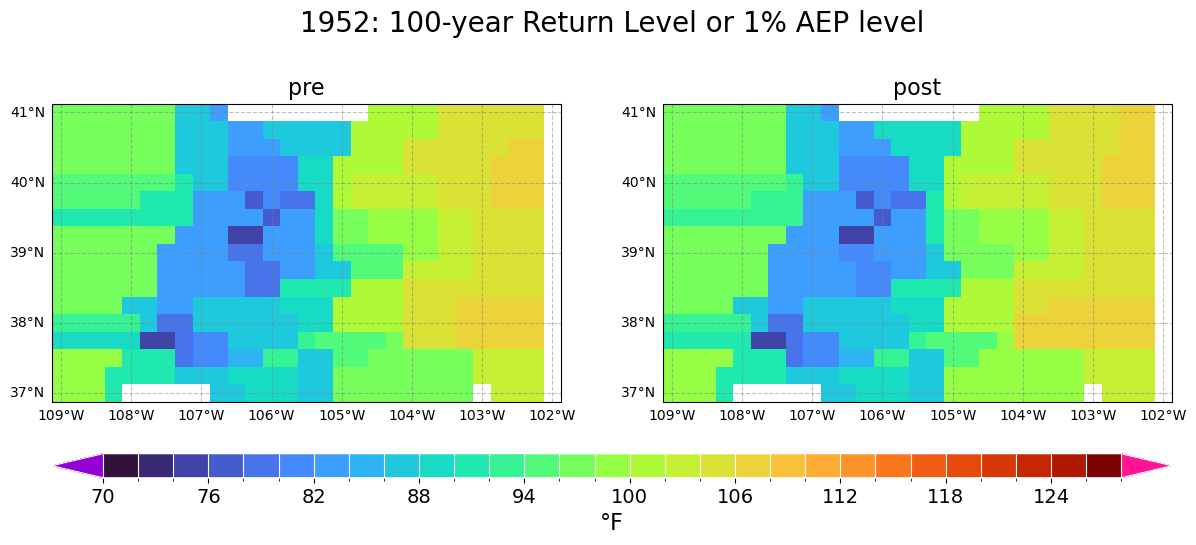

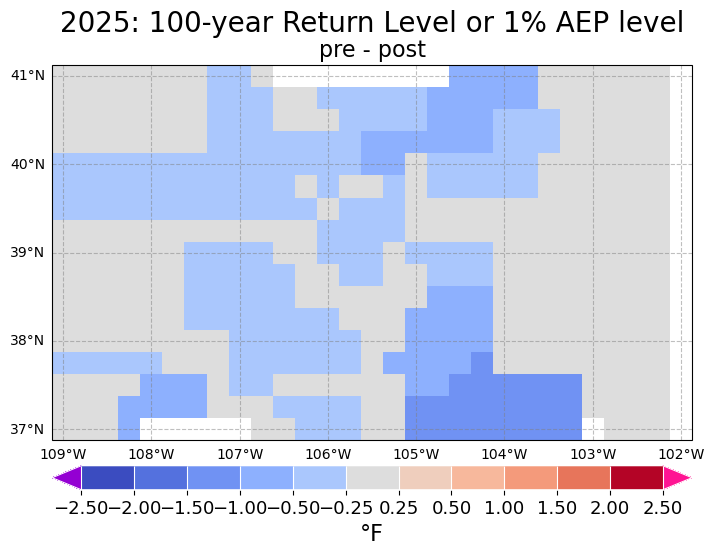

In [138]:
iy=1
for irp in range(len(return_periods)-1,len(return_periods)):
  xxx_pre = np.zeros_like(mask)*np.nan
  xxx_post = np.zeros_like(mask)*np.nan
  for ic in ds['county']:
    xxx_pre = xr.where(mask==ic,ds['rl_pre'].sel(county=ic,return_periods=return_periods[irp],time=Tyears[iy]),xxx_pre)
    xxx_post = xr.where(mask==ic,ds['rl_post'].sel(county=ic,return_periods=return_periods[irp],time=Tyears[iy]),xxx_post)
   
  clevs = np.arange(70,130,2) 
  cmap = plt.get_cmap('turbo',len(clevs)).copy()
  cmap.set_under('darkviolet')
  cmap.set_over('deeppink')
  norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)
  
  fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,6),subplot_kw={'projection':ccrs.PlateCarree()})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.2)
   
  cc=xxx_pre.plot(ax=ax[0],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[0].set_title(f'pre',fontsize=16)
  xxx_post.plot(ax=ax[1],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[1].set_title(f'post',fontsize=16)
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])
  
  for ix in ax:
    gl = ix.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,\
    color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False   # Disable top labels
    gl.right_labels = False # Disable right labels
    
  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both')
  cbar.ax.tick_params(labelsize=14)  
  cbar.set_label(label=units,fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)
  plt.suptitle(f'{Tyears[0]}: {return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  
  plt.show()
  
  ########################################  
  
  clevst = np.arange(-2.5,3,0.5)
  clevs = np.concatenate((np.arange(-2.5,0,0.5),[-0.25,0.25] ,np.arange(0.5,3,0.5)))
  cmap = plt.get_cmap('coolwarm',len(clevs)+1).copy()
  cmap.set_under('darkviolet')
  cmap.set_over('deeppink')
  norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)  
  
  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,6),subplot_kw={'projection':ccrs.PlateCarree()})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
    
  cc=(xxx_pre-xxx_post).plot(ax=ax,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax.set_title(f'pre - post',fontsize=16)

  gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,\
  color="gray", alpha=0.5, linestyle="--")
  gl.top_labels = False   # Disable top labels
  gl.right_labels = False # Disable right labels

  ax_cbar = fig.add_axes([0.1, 0.18, 0.8, 0.04])

  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both')
  cbar.set_ticks(clevs)
  cbar.ax.tick_params(labelsize=13)  
  cbar.set_label(label=units,fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)
  plt.suptitle(f'{Tyears[iy]}: {return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  
  plt.show()
  

## Figure 2. Return-level maps and pre–post differences

**Top figure:** Spatial distribution of TXx return levels across Colorado counties for the selected year and return period. The left panel shows results based on county spatial averages calculated before the GEV analysis, while the right panel shows results based on county spatial averages calculated after the GEV analysis.

**Bottom figure:** Difference between the pre- and post-GEV return levels. Values are calculated as **pre − post**; positive values indicate larger return levels for the county spatial averages calculated before the GEV analysis.

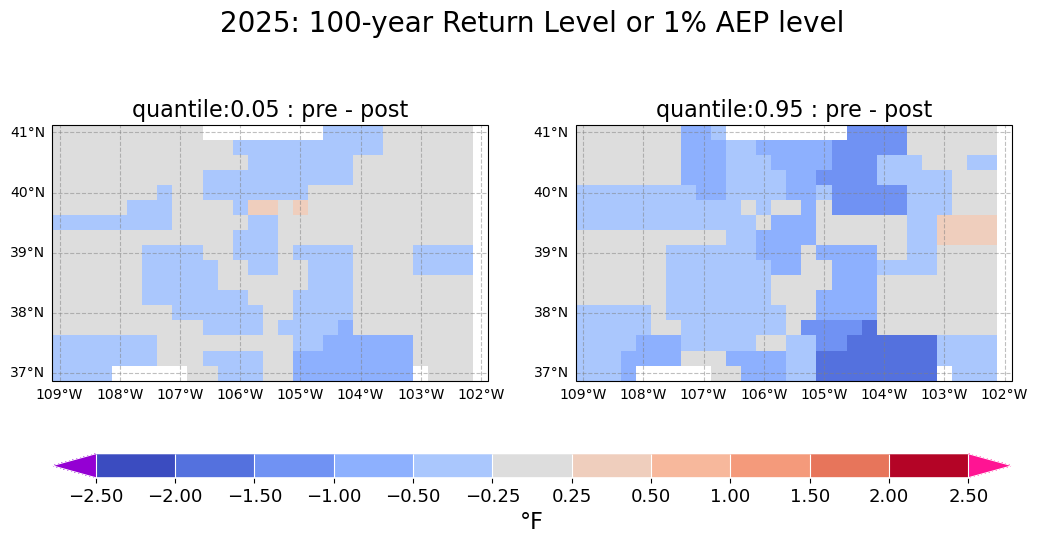

In [139]:
iy=1
for irp in range(len(return_periods)-1,len(return_periods)):
  xxx_pre_q1 = np.zeros_like(mask)*np.nan
  xxx_post_q1 = np.zeros_like(mask)*np.nan
  xxx_pre_q2 = np.zeros_like(mask)*np.nan
  xxx_post_q2 = np.zeros_like(mask)*np.nan
  for ic in ds['county']:
    xxx_pre_q1 = xr.where(mask==ic,ds['rl_q_pre'].sel(county=ic,return_periods=return_periods[irp],time=Tyears[iy],quantile=0.05),xxx_pre_q1)
    xxx_post_q1 = xr.where(mask==ic,ds['rl_q_post'].sel(county=ic,return_periods=return_periods[irp],time=Tyears[iy],quantile=0.05),xxx_post_q1)
    xxx_pre_q2 = xr.where(mask==ic,ds['rl_q_pre'].sel(county=ic,return_periods=return_periods[irp],time=Tyears[iy],quantile=0.95),xxx_pre_q2)
    xxx_post_q2 = xr.where(mask==ic,ds['rl_q_post'].sel(county=ic,return_periods=return_periods[irp],time=Tyears[iy],quantile=0.95),xxx_post_q2)
   
  clevst = np.arange(-2.5,3,0.5)
  clevs = np.concatenate((np.arange(-2.5,0,0.5),[-0.25,0.25] ,np.arange(0.5,3,0.5)))
  cmap = plt.get_cmap('coolwarm',len(clevs)+1).copy()
  cmap.set_under('darkviolet')
  cmap.set_over('deeppink')
  norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N)  
  
  fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,6),subplot_kw={'projection':ccrs.PlateCarree()})
  plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.2)
  
    
  cc=(xxx_pre_q1-xxx_post_q1).plot(ax=ax[0],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[0].set_title(f'quantile:0.05 : pre - post',fontsize=16)
  cc=(xxx_pre_q2-xxx_post_q2).plot(ax=ax[1],cmap=cmap,norm=norm,transform=ccrs.PlateCarree(),add_colorbar=False)
  ax[1].set_title(f'quantile:0.95 : pre - post',fontsize=16)
  ax_cbar = fig.add_axes([0.1, 0.2, 0.8, 0.04])

  for ix in ax:
    gl = ix.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,\
    color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False   # Disable top labels
    gl.right_labels = False # Disable right labels


  cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',drawedges=True,extend='both')
  cbar.set_ticks(clevs)
  cbar.ax.tick_params(labelsize=13)  
  cbar.set_label(label=units,fontsize=16)  
  cbar.outline.set_edgecolor('w')
  cbar.dividers.set_edgecolor('w')
  cbar.dividers.set_linewidth(0.8)
  plt.suptitle(f'{Tyears[iy]}: {return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  
  plt.show()
  

## Figure 4. Quantile-difference maps

**Caption:** Difference between pre- and post-GEV TXx return-level estimates at the 5th and 95th uncertainty quantiles. The left and right panels show the differences at the 0.05 and 0.95 quantiles, respectively. Values are calculated as **pre − post**.

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_94984/628476701.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('turbo',ncounties)
/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_94984/628476701.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  maskic.plot(ax=ax,cmap=cm.get_cmap('turbo',ncounties),levels=np.arange(0,ncounties+1,1),add_colorbar=False)


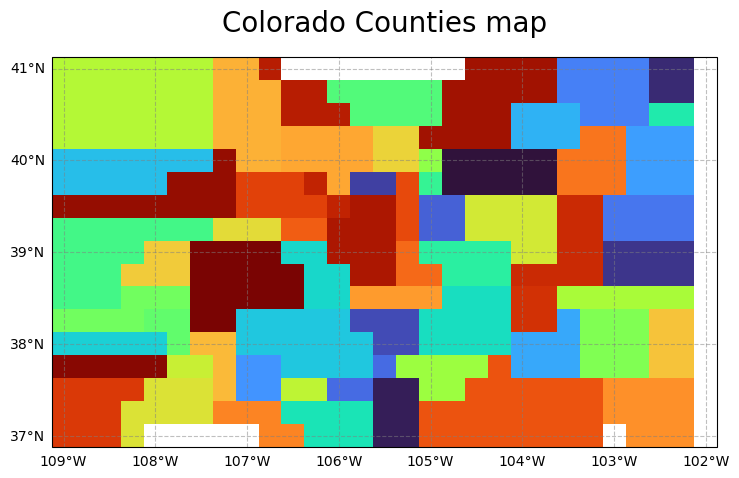

In [140]:
colors = cm.get_cmap('turbo',ncounties)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,6),subplot_kw={'projection':ccrs.PlateCarree()})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

maskic.plot(ax=ax,cmap=cm.get_cmap('turbo',ncounties),levels=np.arange(0,ncounties+1,1),add_colorbar=False)

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,\
    color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False   # Disable top labels
gl.right_labels = False # Disable right labels

plt.suptitle(f'Colorado Counties map',fontsize=20)  
plt.show()

## Figure 5. County map values

**Caption:** Colorado county map showing the spatial assignment of grid cells used in the time-series analysis. Each color represents a different county.

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_94984/4055987076.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('turbo',ncounties)


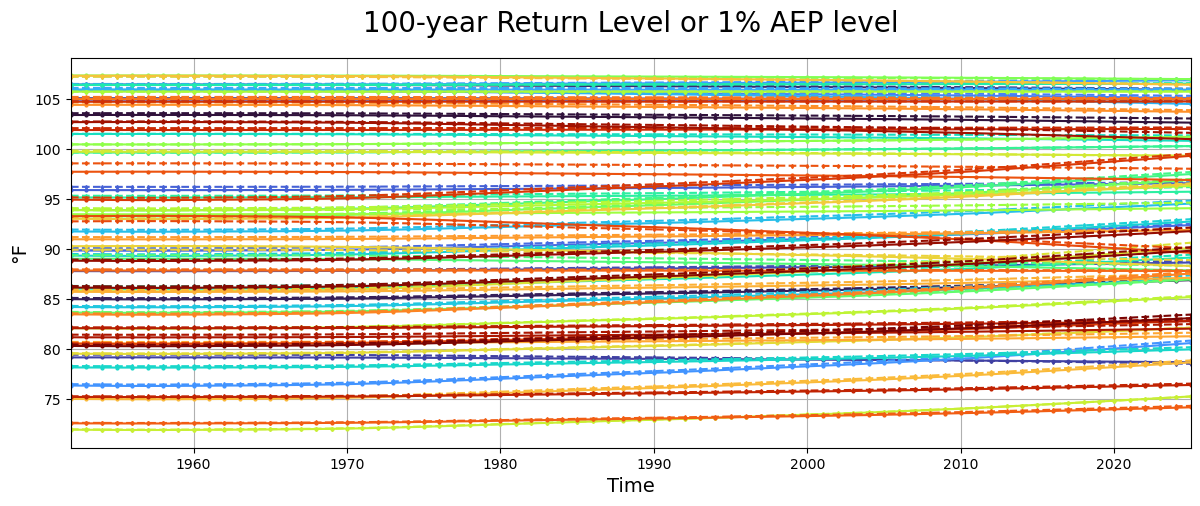

In [144]:
irp = len(return_periods)-1

colors = cm.get_cmap('turbo',ncounties)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,6))
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)

for ic in range(0,ncounties):
  icounty = ds['county'][ic].data.item()
  if ds['rl_post'].sel(county=icounty,return_periods=return_periods[irp]).isnull().all()==False:
    cc=ds['rl_pre'].sel(county=icounty,return_periods=return_periods[irp]).plot(ax=ax,color=colors(ic),marker='o',markersize=2)
    cc=ds['rl_post'].sel(county=icounty,return_periods=return_periods[irp]).plot(ax=ax,color=colors(ic),marker='d',markersize=2,ls='--')
ax.set_ylabel(f'{units}',fontsize=14)
ax.set_xlabel('Time',fontsize=14)
ax.set_xlim(Tyears[0],Tyears[1])
ax.grid()
ax.set_title('')

plt.suptitle(f'{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level',fontsize=20)  
plt.show()

## Figure 6. County return-level time series

**Caption:** Temporal evolution of TXx return levels for Colorado counties at the selected return period. Circles and solid lines represent county spatial averages calculated before the GEV analysis, while diamonds and dashed lines represent county spatial averages calculated after the GEV analysis. Each color corresponds to a different county. Line colors correspond to the county assignments shown in Figure 5, allowing identification of individual counties across the time-series analyses.

/var/folders/41/jpdddhvx1_bfhbywzg083cy00000gt/T/ipykernel_94984/1909501034.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('turbo',ncounties)


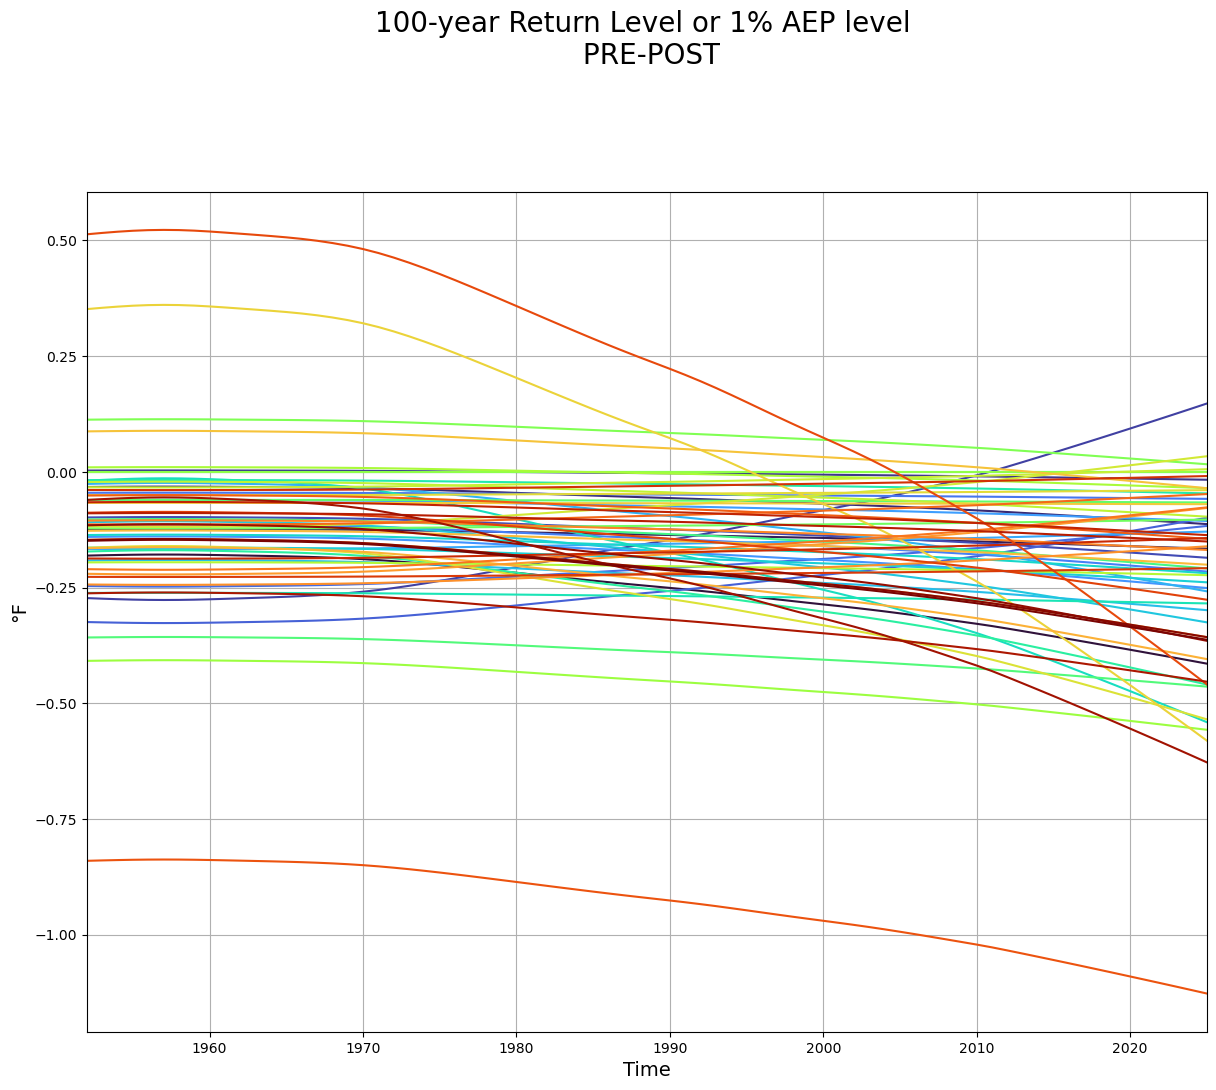

In [143]:
irp = len(return_periods)-1

colors = cm.get_cmap('turbo',ncounties)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(14,14))
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.85,hspace=0.2,wspace=0.04)

for ic in range(0,ncounties):
  icounty = ds['county'][ic].data.item()
  if ds['rl_post'].sel(county=icounty,return_periods=return_periods[irp]).isnull().all()==False:
    cc=(ds['rl_pre'].sel(county=icounty,return_periods=return_periods[irp])-\
        ds['rl_post'].sel(county=icounty,return_periods=return_periods[irp])).plot(ax=ax,color=colors(ic))
ax.set_ylabel(f'{units}',fontsize=14)
ax.set_xlabel('Time',fontsize=14)
ax.grid()
ax.set_title('')
ax.set_xlim(Tyears[0],Tyears[1])

plt.suptitle(f'{return_periods[irp]}-year Return Level or {AEP[irp]*100:.0f}% AEP level \n PRE-POST',fontsize=20)  
plt.show()

## Figure 7. Pre–post return-level differences through time

**Caption:** Time series of the difference between TXx return levels based on county spatial averages calculated before and after the GEV analysis. Values are calculated as **pre − post**; positive values indicate larger return levels for the pre-GEV county spatial averages. Line colors correspond to the county assignments shown in Figure 5, allowing identification of individual counties across the time-series analyses.